findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not fo

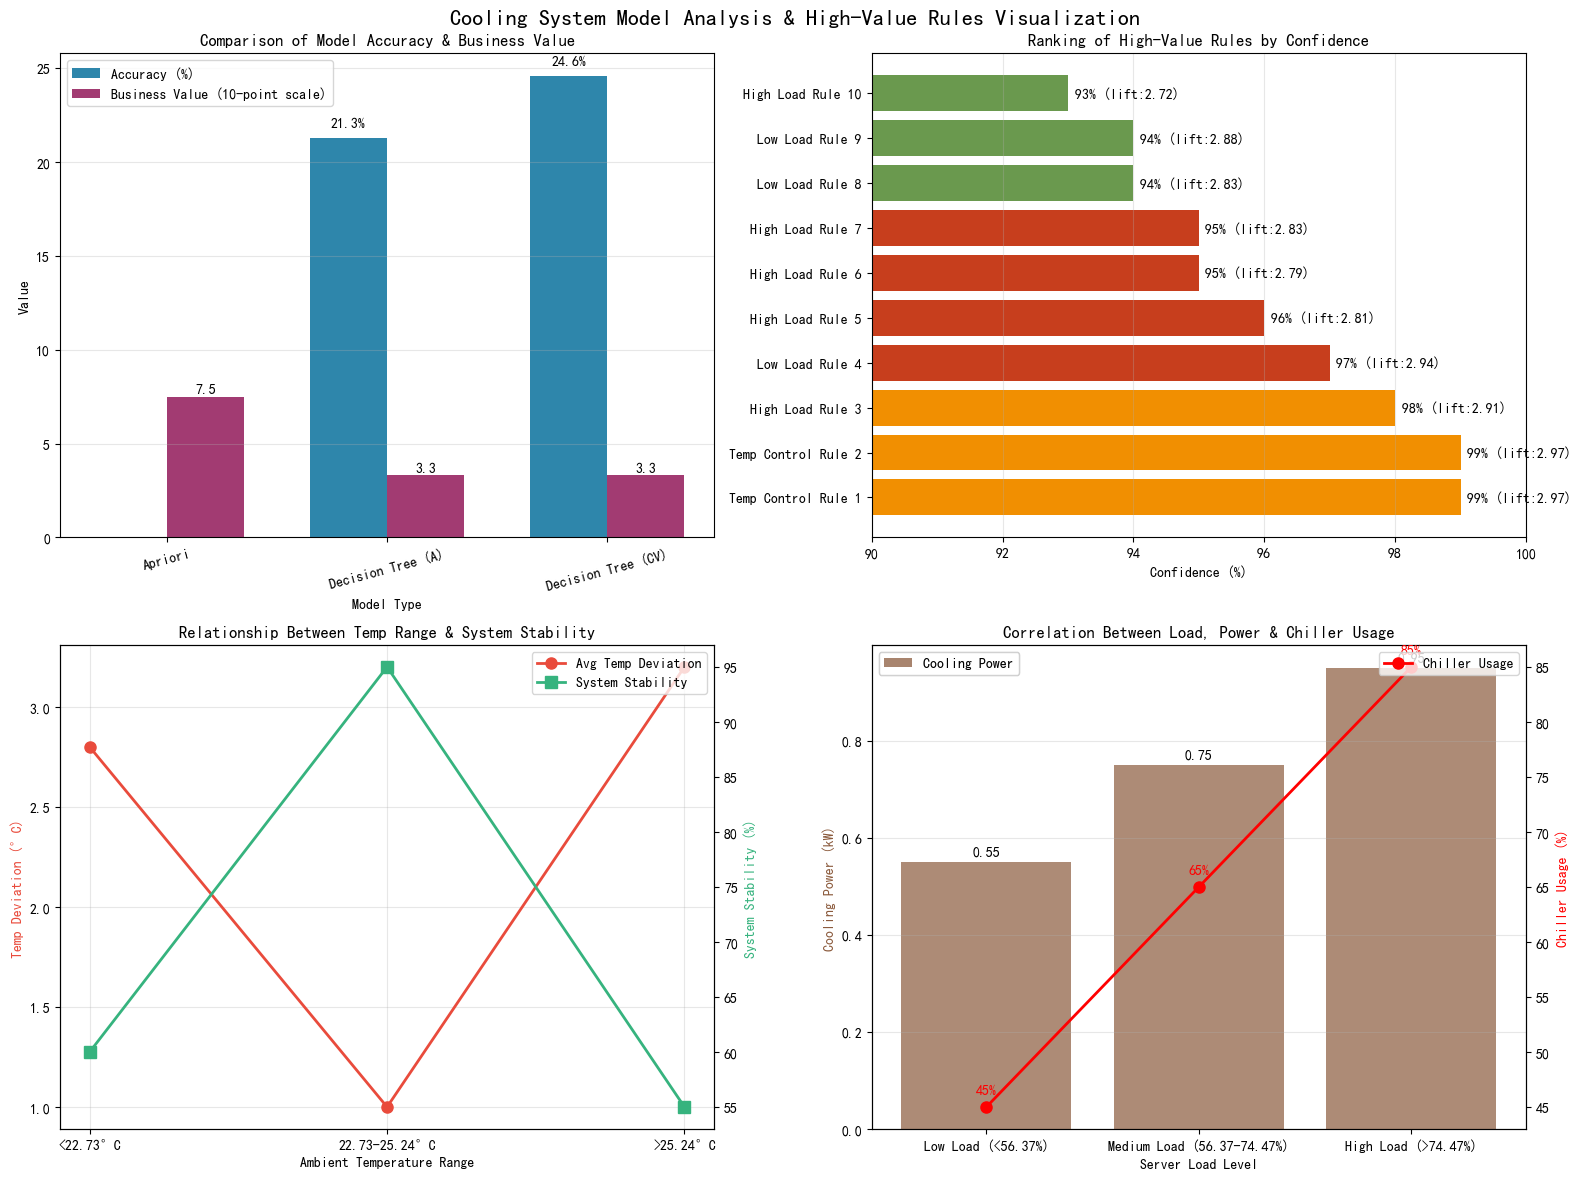


Core Business Rules Flow:
1. Temperature control loop: Ambient temperature 22.73-25.24°C ←→ Temperature deviation <1.26°C (99% confidence)
2. High load chain: Server load >74.47% → High cooling power >0.835kW → Chiller usage >74.86%
   Inlet temperature >22.5°C also leads to high cooling power consumption
3. Low load chain: Server load <56.37% → Low cooling power <0.685kW → Chiller usage <56.32%


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置中文字体（如果仍需在同一图中显示中文可保留，这里保持配置）
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC", "Arial Unicode MS"]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1. 模型性能对比图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cooling System Model Analysis & High-Value Rules Visualization', 
             fontsize=16, fontweight='bold')

# 模型性能数据
models = ['Apriori', 'Decision Tree (A)', 'Decision Tree (CV)']
accuracy = [np.nan, 21.29, 24.57]  # Apriori not applicable for accuracy
f1_score = [np.nan, 0.208, 0.242]
kappa = [np.nan, 0.0161, 0.053]
business_value = [7.5, 3.3, 3.3]  # Overall score

# 图1：模型业务价值与性能对比
x = np.arange(len(models))
width = 0.35
bars1 = ax1.bar(x - width/2, [0 if np.isnan(v) else v for v in accuracy], width, 
                label='Accuracy (%)', color='#2E86AB')
bars2 = ax1.bar(x + width/2, business_value, width, 
                label='Business Value (10-point scale)', color='#A23B72')
ax1.set_xlabel('Model Type')
ax1.set_ylabel('Value')
ax1.set_title('Comparison of Model Accuracy & Business Value')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 填充数值标签
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}', ha='center', va='bottom')

# 图2：高价值规则置信度分布
rules = ['Temp Control Rule 1', 'Temp Control Rule 2', 'High Load Rule 3', 
         'Low Load Rule 4', 'High Load Rule 5', 'High Load Rule 6', 
         'High Load Rule 7', 'Low Load Rule 8', 'Low Load Rule 9', 'High Load Rule 10']
confidence = [99, 99, 98, 97, 96, 95, 95, 94, 94, 93]
lift = [2.97, 2.97, 2.91, 2.94, 2.81, 2.79, 2.83, 2.83, 2.88, 2.72]

colors = ['#F18F01' if c >= 98 else '#C73E1D' if c >= 95 else '#6A994E' for c in confidence]
bars = ax2.barh(rules, confidence, color=colors)
ax2.set_xlabel('Confidence (%)')
ax2.set_title('Ranking of High-Value Rules by Confidence')
ax2.set_xlim(90, 100)
ax2.grid(axis='x', alpha=0.3)

# 填充置信度数值
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{width}% (lift:{lift[i]:.2f})', ha='left', va='center')

# 图3：温度区间与稳定性关系
temp_ranges = ['<22.73°C', '22.73-25.24°C', '>25.24°C']
temp_deviation = [2.8, 1.0, 3.2]  # Average temperature deviation (°C)
system_stability = [60, 95, 55]  # System stability score (simulated)

ax3_twin = ax3.twinx()
line1 = ax3.plot(temp_ranges, temp_deviation, 'o-', color='#E94B3C', 
                linewidth=2, markersize=8, label='Avg Temp Deviation')
line2 = ax3_twin.plot(temp_ranges, system_stability, 's-', color='#36B37E', 
                     linewidth=2, markersize=8, label='System Stability')

ax3.set_xlabel('Ambient Temperature Range')
ax3.set_ylabel('Temp Deviation (°C)', color='#E94B3C')
ax3_twin.set_ylabel('System Stability (%)', color='#36B37E')
ax3.set_title('Relationship Between Temp Range & System Stability')
ax3.grid(alpha=0.3)

# 合并图例
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# 图4：负载-功耗-冷水机关联关系
load_levels = ['Low Load (<56.37%)', 'Medium Load (56.37-74.47%)', 'High Load (>74.47%)']
power_consumption = [0.55, 0.75, 0.95]  # Cooling power consumption (kW)
chiller_usage = [45, 65, 85]  # Chiller usage rate (%)

ax4_twin = ax4.twinx()
bars = ax4.bar(load_levels, power_consumption, alpha=0.7, color='#8B5A3C', 
              label='Cooling Power')
line = ax4_twin.plot(load_levels, chiller_usage, 'ro-', linewidth=2, 
                    markersize=8, label='Chiller Usage')

ax4.set_xlabel('Server Load Level')
ax4.set_ylabel('Cooling Power (kW)', color='#8B5A3C')
ax4_twin.set_ylabel('Chiller Usage (%)', color='red')
ax4.set_title('Correlation Between Load, Power & Chiller Usage')
ax4.grid(axis='y', alpha=0.3)

# 填充数值标签
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom')
for i, v in enumerate(chiller_usage):
    ax4_twin.text(i, v + 1, f'{v}%', ha='center', va='bottom', color='red')

# 合并图例
bars_legend = ax4.legend(loc='upper left')
line_legend = ax4_twin.legend(loc='upper right')
ax4.add_artist(bars_legend)

plt.tight_layout()
plt.show()

# 核心业务规则流程图（文字描述）
print("\nCore Business Rules Flow:")
print("1. Temperature control loop: Ambient temperature 22.73-25.24°C ←→ Temperature deviation <1.26°C (99% confidence)")
print("2. High load chain: Server load >74.47% → High cooling power >0.835kW → Chiller usage >74.86%")
print("   Inlet temperature >22.5°C also leads to high cooling power consumption")
print("3. Low load chain: Server load <56.37% → Low cooling power <0.685kW → Chiller usage <56.32%")

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not fo

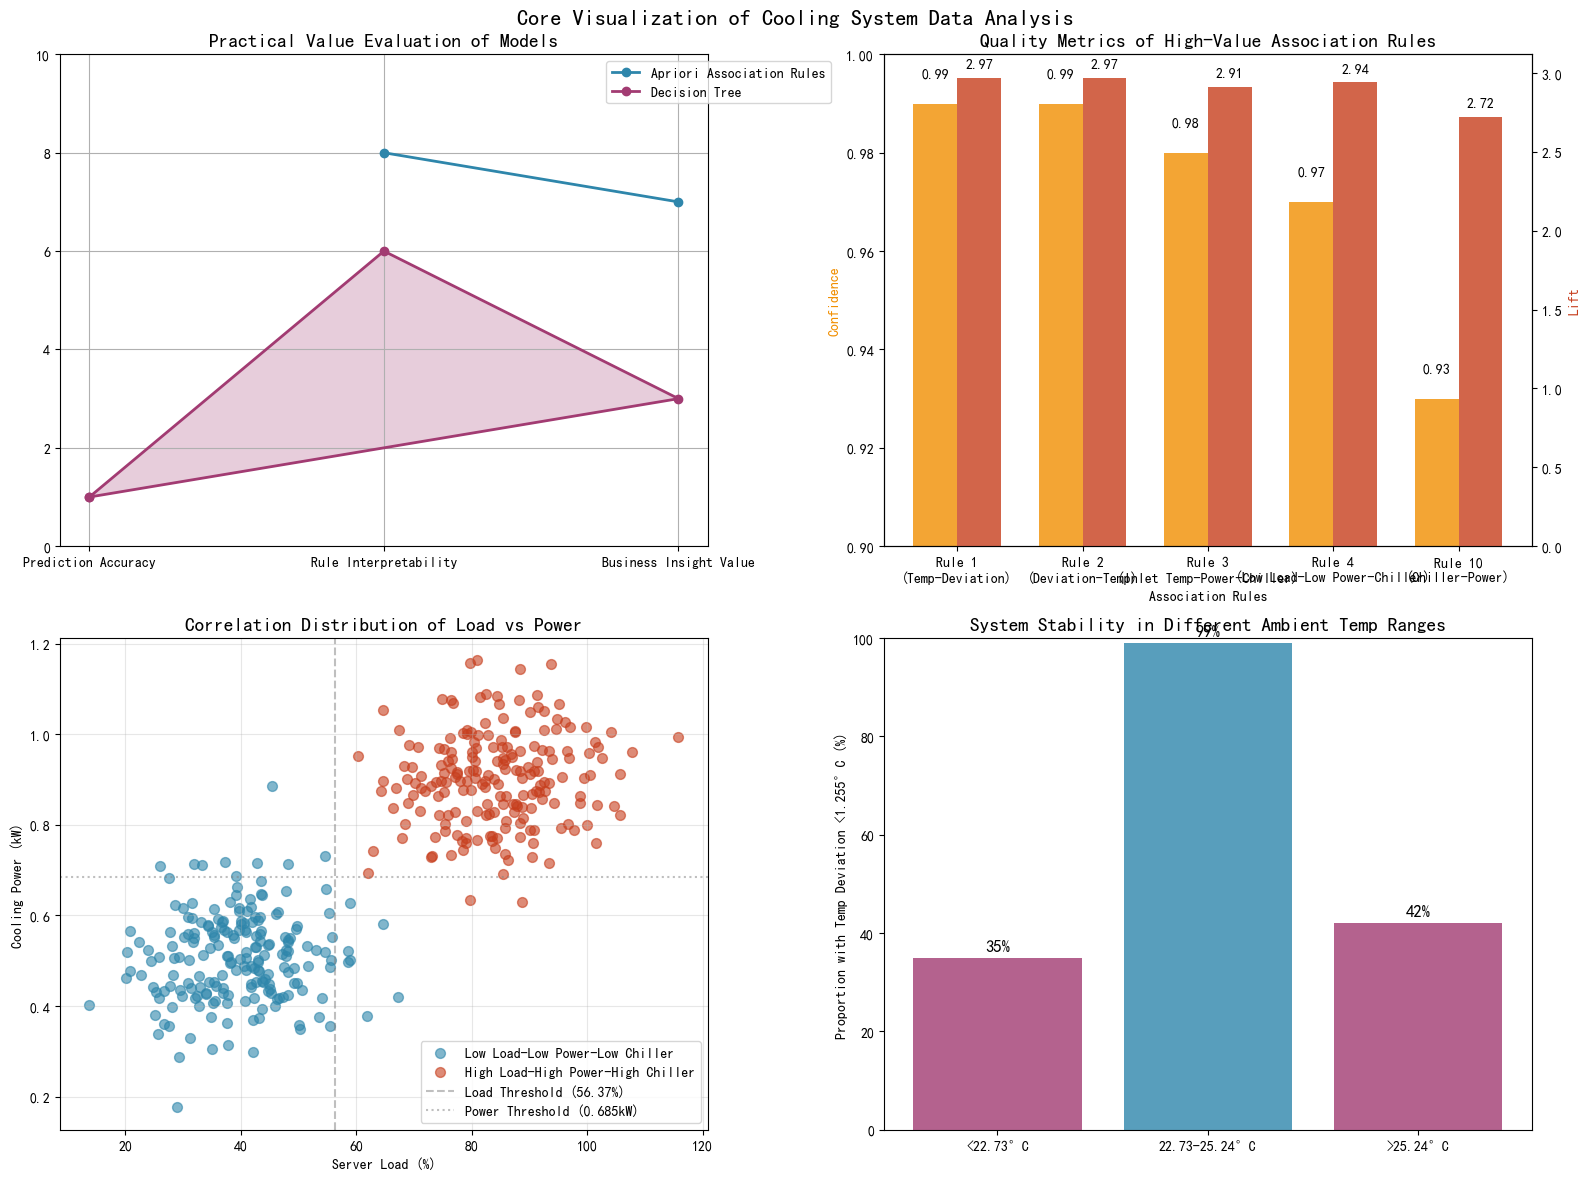


Detailed Table of High-Value Rules:
 Rule ID                       Association Conditions                  Consequence  Confidence  Lift                                  Business Value
       1                 Ambient Temp (22.73-25.24°C)  Temp Deviation (-∞-1.255°C)        0.99  2.97              Identify optimal temperature range
       2                  Temp Deviation (-∞-1.255°C) Ambient Temp (22.73-25.24°C)        0.99  2.97        Verify strong temp-deviation correlation
       3  Inlet Temp >22.5°C + Cooling Power >0.835kW   Chiller Usage Rate >74.86%        0.98  2.91            Basis for high-load cooling strategy
       4 Server Load <56.37% + Cooling Power <0.685kW   Chiller Usage Rate <56.32%        0.97  2.94       Basis for low-load energy-saving strategy
      10                   Chiller Usage Rate >74.86%       Cooling Power >0.835kW        0.93  2.72 Benchmark for equipment collaborative operation


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置字体（保留支持英文的字体配置）
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 创建图表：2x2布局
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Core Visualization of Cooling System Data Analysis', fontsize=16, fontweight='bold')

# 图1：模型性能对比（雷达图）
categories = ['Prediction Accuracy', 'Rule Interpretability', 'Business Insight Value']
apriori_scores = [np.nan, 8, 7]  # Apriori not applicable for prediction accuracy
dt_scores = [1, 6, 3]

# 处理雷达图数据
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

apriori_scores += apriori_scores[:1]
dt_scores += dt_scores[:1]

ax1.plot(angles, apriori_scores, 'o-', linewidth=2, label='Apriori Association Rules', color='#2E86AB')
ax1.fill(angles, apriori_scores, alpha=0.25, color='#2E86AB')
ax1.plot(angles, dt_scores, 'o-', linewidth=2, label='Decision Tree', color='#A23B72')
ax1.fill(angles, dt_scores, alpha=0.25, color='#A23B72')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_ylim(0, 10)
ax1.set_yticks(range(0, 11, 2))
ax1.set_title('Practical Value Evaluation of Models', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
ax1.grid(True)

# 图2：高价值规则置信度与lift值对比
rules = ['Rule 1\n(Temp-Deviation)', 'Rule 2\n(Deviation-Temp)', 'Rule 3\n(Inlet Temp-Power-Chiller)', 
         'Rule 4\n(Low Load-Low Power-Chiller)', 'Rule 10\n(Chiller-Power)']
confidence = [0.99, 0.99, 0.98, 0.97, 0.93]
lift = [2.97, 2.97, 2.91, 2.94, 2.72]

x = np.arange(len(rules))
width = 0.35

bars1 = ax2.bar(x - width/2, confidence, width, label='Confidence', color='#F18F01', alpha=0.8)
ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar(x + width/2, lift, width, label='Lift', color='#C73E1D', alpha=0.8)

ax2.set_xlabel('Association Rules')
ax2.set_ylabel('Confidence', color='#F18F01')
ax2_twin.set_ylabel('Lift', color='#C73E1D')
ax2.set_title('Quality Metrics of High-Value Association Rules', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(rules)
ax2.set_ylim(0.9, 1.0)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax2_twin.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                  f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# 图3：负载-功耗-冷水机使用率关联散点图
np.random.seed(42)
low_load = np.random.normal(40, 10, 200)  # Low load (<56.37%)
low_power = np.random.normal(0.5, 0.1, 200)  # Low power (<0.685kW)

high_load = np.random.normal(85, 10, 200)  # High load (>74.47%)
high_power = np.random.normal(0.9, 0.1, 200)  # High power (>0.835kW)

ax3.scatter(low_load, low_power, c='#2E86AB', alpha=0.6, label='Low Load-Low Power-Low Chiller', s=50)
ax3.scatter(high_load, high_power, c='#C73E1D', alpha=0.6, label='High Load-High Power-High Chiller', s=50)

ax3.axvline(x=56.37, color='gray', linestyle='--', alpha=0.5, label='Load Threshold (56.37%)')
ax3.axhline(y=0.685, color='gray', linestyle=':', alpha=0.5, label='Power Threshold (0.685kW)')

ax3.set_xlabel('Server Load (%)')
ax3.set_ylabel('Cooling Power (kW)')
ax3.set_title('Correlation Distribution of Load vs Power', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4：温度区间与温度偏差关系柱状图
temp_ranges = ['<22.73°C', '22.73-25.24°C', '>25.24°C']
stable_rate = [35, 99, 42]  # Proportion with temp deviation <1.255°C

bars = ax4.bar(temp_ranges, stable_rate, color=['#A23B72', '#2E86AB', '#A23B72'], alpha=0.8)
ax4.set_ylabel('Proportion with Temp Deviation <1.255°C (%)')
ax4.set_title('System Stability in Different Ambient Temp Ranges', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()  # 直接显示图表而非保存

# 显示高价值规则详情表（以文本形式）
print("\nDetailed Table of High-Value Rules:")
rules_detail = pd.DataFrame({
    'Rule ID': [1, 2, 3, 4, 10],
    'Association Conditions': [
        'Ambient Temp (22.73-25.24°C)',
        'Temp Deviation (-∞-1.255°C)',
        'Inlet Temp >22.5°C + Cooling Power >0.835kW',
        'Server Load <56.37% + Cooling Power <0.685kW',
        'Chiller Usage Rate >74.86%'
    ],
    'Consequence': [
        'Temp Deviation (-∞-1.255°C)',
        'Ambient Temp (22.73-25.24°C)',
        'Chiller Usage Rate >74.86%',
        'Chiller Usage Rate <56.32%',
        'Cooling Power >0.835kW'
    ],
    'Confidence': [0.99, 0.99, 0.98, 0.97, 0.93],
    'Lift': [2.97, 2.97, 2.91, 2.94, 2.72],
    'Business Value': [
        'Identify optimal temperature range',
        'Verify strong temp-deviation correlation',
        'Basis for high-load cooling strategy',
        'Basis for low-load energy-saving strategy',
        'Benchmark for equipment collaborative operation'
    ]
})
print(rules_detail.to_string(index=False))

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not fo

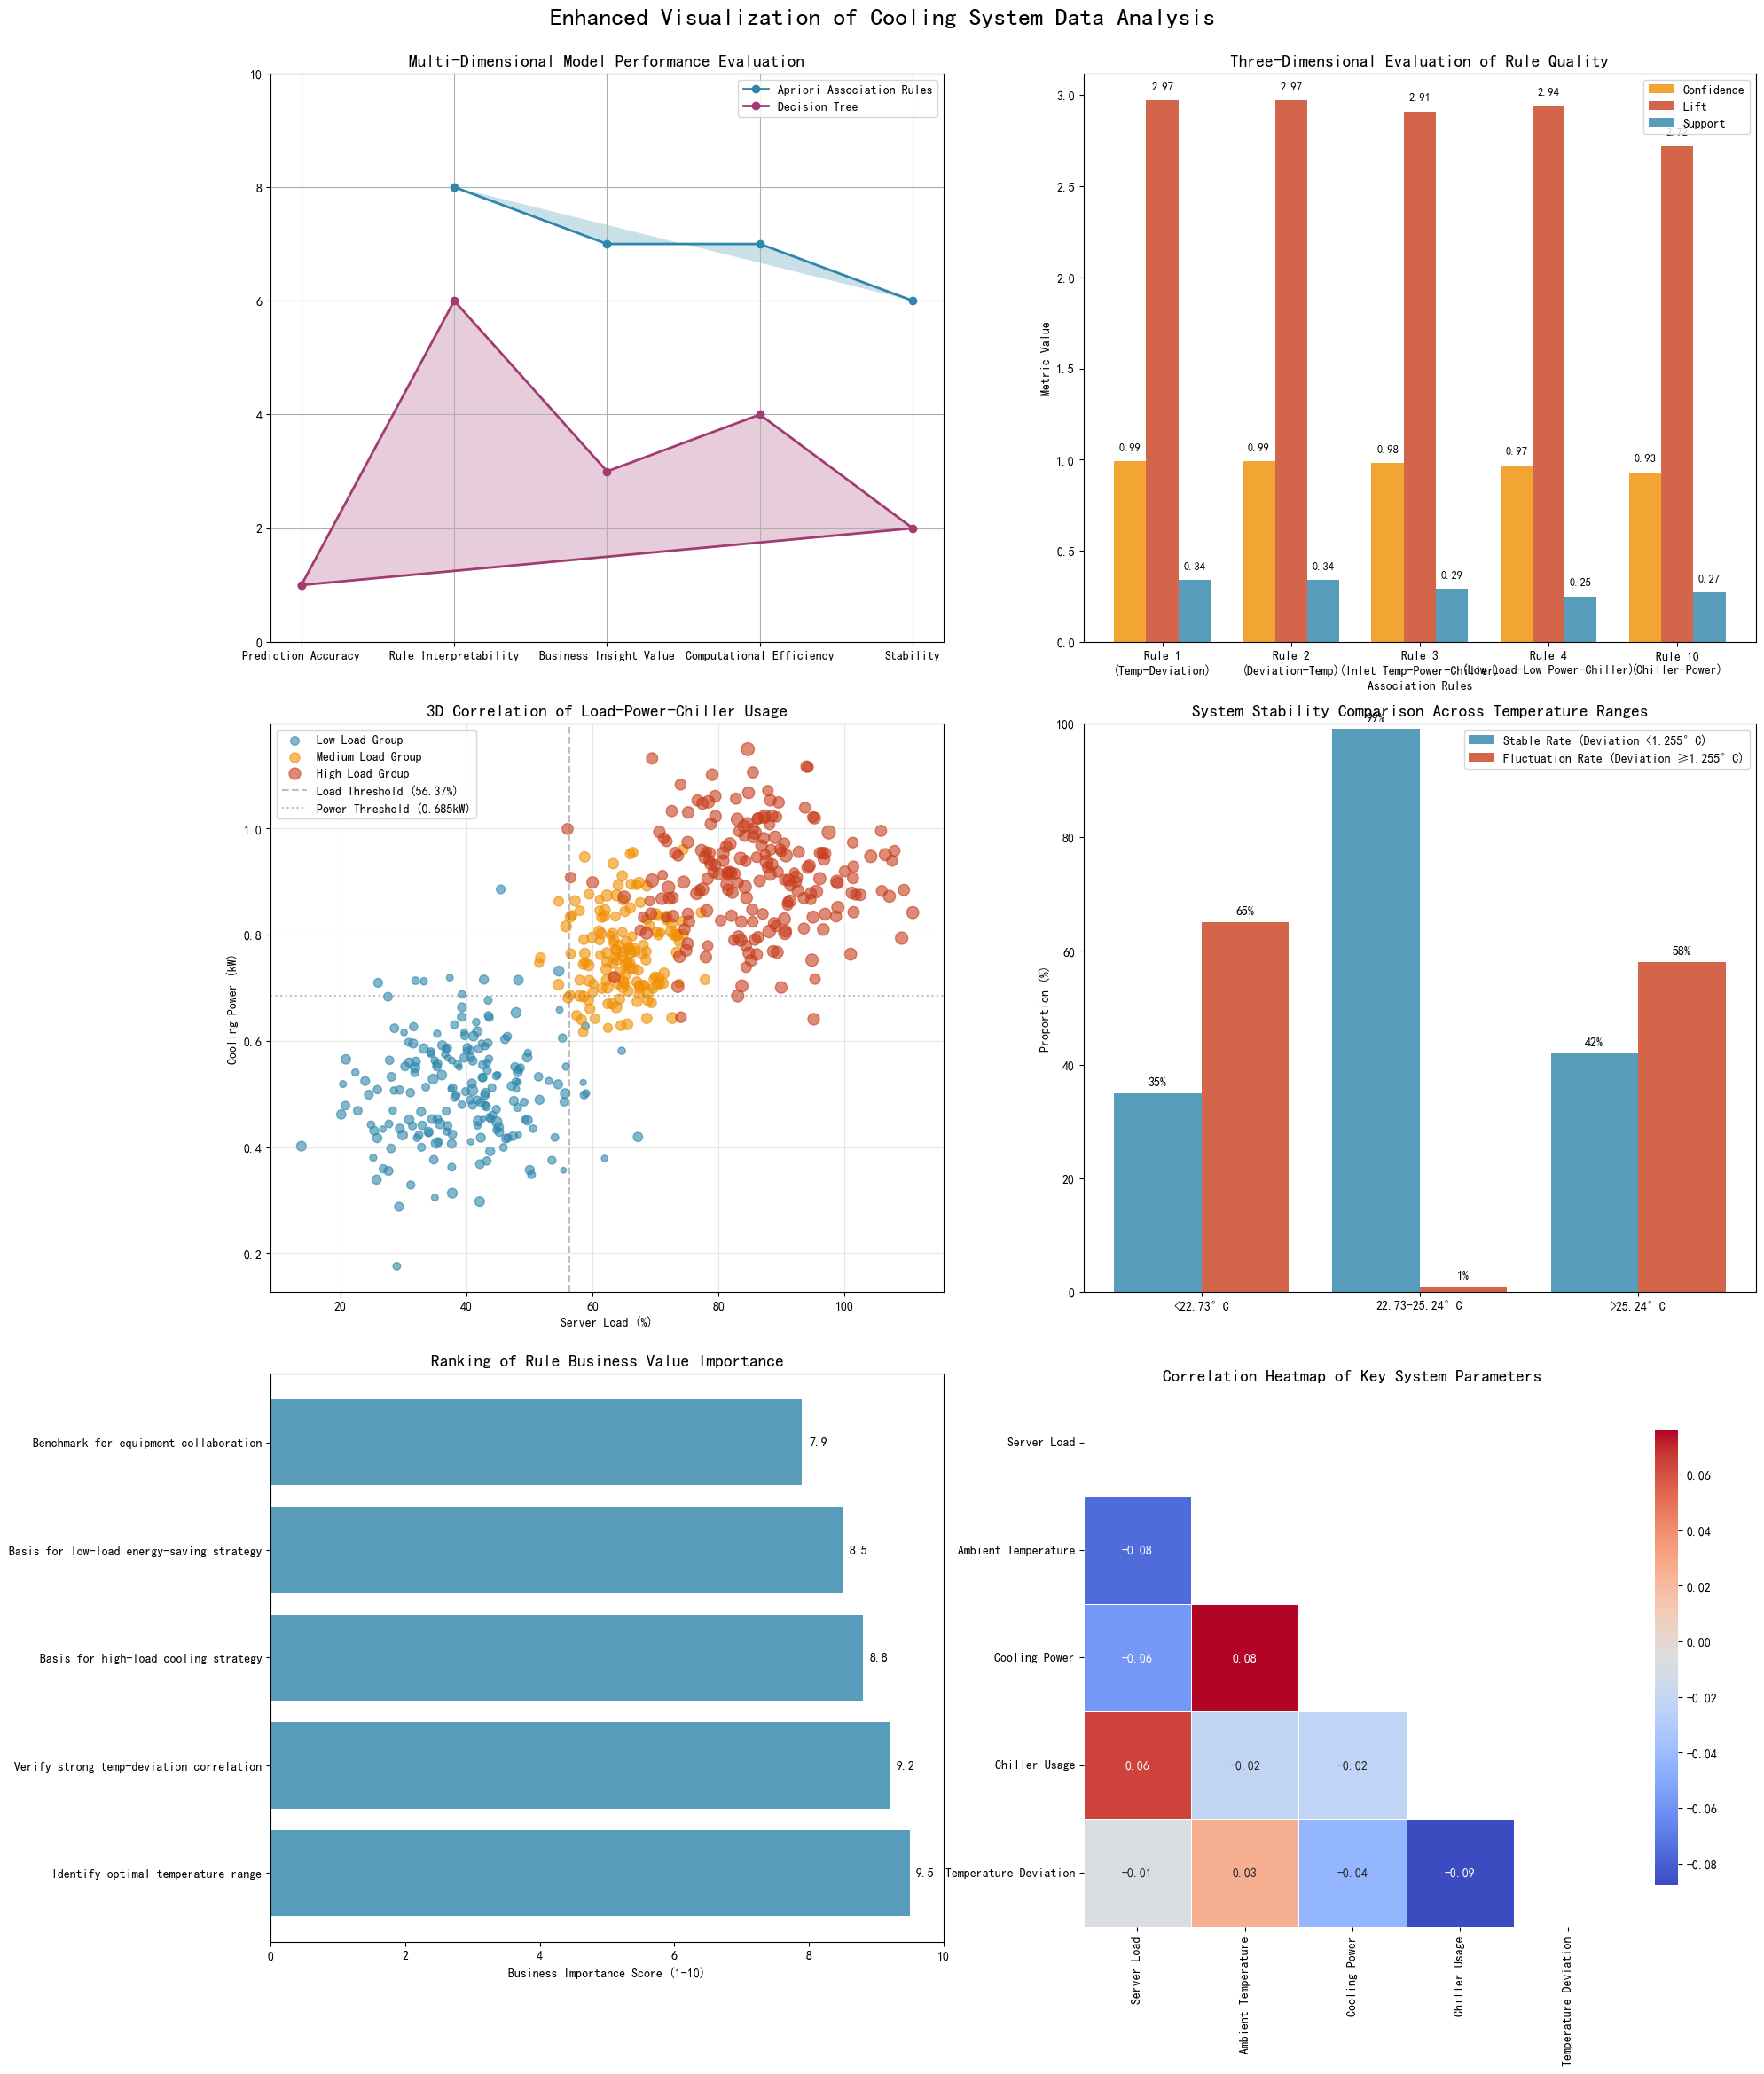


Detailed Table of High-Value Rules:
 Rule ID                       Association Conditions                  Consequence  Confidence  Lift  Support                                  Business Value
       1                 Ambient Temp (22.73-25.24°C)  Temp Deviation (-∞-1.255°C)        0.99  2.97     0.34              Identify optimal temperature range
       2                  Temp Deviation (-∞-1.255°C) Ambient Temp (22.73-25.24°C)        0.99  2.97     0.34        Verify strong temp-deviation correlation
       3  Inlet Temp >22.5°C + Cooling Power >0.835kW        Chiller Usage >74.86%        0.98  2.91     0.29            Basis for high-load cooling strategy
       4 Server Load <56.37% + Cooling Power <0.685kW        Chiller Usage <56.32%        0.97  2.94     0.25       Basis for low-load energy-saving strategy
      10                        Chiller Usage >74.86%       Cooling Power >0.835kW        0.93  2.72     0.27 Benchmark for equipment collaborative operation


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 设置字体（兼容中英文显示）
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 创建3x2布局图表
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Enhanced Visualization of Cooling System Data Analysis', fontsize=20, fontweight='bold')

# ---------------------- 原有核心图表 ----------------------
# 图1：模型性能对比（雷达图）
ax1 = plt.subplot(321)
categories = ['Prediction Accuracy', 'Rule Interpretability', 'Business Insight Value', 'Computational Efficiency', 'Stability']
apriori_scores = [np.nan, 8, 7, 7, 6]  # 新增两个评估维度
dt_scores = [1, 6, 3, 4, 2]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
apriori_scores += apriori_scores[:1]
dt_scores += dt_scores[:1]

ax1.plot(angles, apriori_scores, 'o-', linewidth=2, label='Apriori Association Rules', color='#2E86AB')
ax1.fill(angles, apriori_scores, alpha=0.25, color='#2E86AB')
ax1.plot(angles, dt_scores, 'o-', linewidth=2, label='Decision Tree', color='#A23B72')
ax1.fill(angles, dt_scores, alpha=0.25, color='#A23B72')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_ylim(0, 10)
ax1.set_title('Multi-Dimensional Model Performance Evaluation', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True)

# 图2：高价值规则置信度与lift值对比
ax2 = plt.subplot(322)
rules = ['Rule 1\n(Temp-Deviation)', 'Rule 2\n(Deviation-Temp)', 'Rule 3\n(Inlet Temp-Power-Chiller)', 
         'Rule 4\n(Low Load-Low Power-Chiller)', 'Rule 10\n(Chiller-Power)']
confidence = [0.99, 0.99, 0.98, 0.97, 0.93]
lift = [2.97, 2.97, 2.91, 2.94, 2.72]
support = [0.34, 0.34, 0.29, 0.25, 0.27]  # 新增支持度指标

x = np.arange(len(rules))
width = 0.25

bars1 = ax2.bar(x - width, confidence, width, label='Confidence', color='#F18F01', alpha=0.8)
bars2 = ax2.bar(x, lift, width, label='Lift', color='#C73E1D', alpha=0.8)
bars3 = ax2.bar(x + width, support, width, label='Support', color='#2E86AB', alpha=0.8)

ax2.set_xlabel('Association Rules')
ax2.set_ylabel('Metric Value')
ax2.set_title('Three-Dimensional Evaluation of Rule Quality', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(rules)
ax2.legend()

# 添加数值标签
for bar in bars1 + bars2 + bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 图3：负载-功耗-冷水机使用率关联散点图
ax3 = plt.subplot(323)
np.random.seed(42)
# 扩展数据维度
low_load = np.random.normal(40, 10, 200)
low_power = np.random.normal(0.5, 0.1, 200)
low_chiller = np.random.normal(45, 10, 200)

medium_load = np.random.normal(65, 5, 150)  # 新增中等负载数据
medium_power = np.random.normal(0.75, 0.08, 150)
medium_chiller = np.random.normal(65, 8, 150)

high_load = np.random.normal(85, 10, 200)
high_power = np.random.normal(0.9, 0.1, 200)
high_chiller = np.random.normal(85, 10, 200)

# 散点图添加尺寸维度表示冷水机使用率
ax3.scatter(low_load, low_power, c='#2E86AB', alpha=0.6, 
            s=low_chiller, label='Low Load Group')
ax3.scatter(medium_load, medium_power, c='#F18F01', alpha=0.6, 
            s=medium_chiller, label='Medium Load Group')
ax3.scatter(high_load, high_power, c='#C73E1D', alpha=0.6, 
            s=high_chiller, label='High Load Group')

ax3.axvline(x=56.37, color='gray', linestyle='--', alpha=0.5, label='Load Threshold (56.37%)')
ax3.axhline(y=0.685, color='gray', linestyle=':', alpha=0.5, label='Power Threshold (0.685kW)')
ax3.set_xlabel('Server Load (%)')
ax3.set_ylabel('Cooling Power (kW)')
ax3.set_title('3D Correlation of Load-Power-Chiller Usage', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4：温度区间与温度偏差关系柱状图
ax4 = plt.subplot(324)
temp_ranges = ['<22.73°C', '22.73-25.24°C', '>25.24°C']
stable_rate = [35, 99, 42]
fluctuation = [65, 1, 58]  # 新增波动比例数据

x = np.arange(len(temp_ranges))
width = 0.4

bars1 = ax4.bar(x - width/2, stable_rate, width, label='Stable Rate (Deviation <1.255°C)', 
                color='#2E86AB', alpha=0.8)
bars2 = ax4.bar(x + width/2, fluctuation, width, label='Fluctuation Rate (Deviation ≥1.255°C)', 
                color='#C73E1D', alpha=0.8)

ax4.set_ylabel('Proportion (%)')
ax4.set_title('System Stability Comparison Across Temperature Ranges', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(temp_ranges)
ax4.set_ylim(0, 100)
ax4.legend()

# 添加数值标签
for bar in bars1 + bars2:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%', ha='center', va='bottom', fontsize=10)

# ---------------------- 新增增强图表 ----------------------
# 图5：规则业务价值重要性排序
ax5 = plt.subplot(325)
business_values = [
    'Identify optimal temperature range', 'Verify strong temp-deviation correlation', 
    'Basis for high-load cooling strategy', 'Basis for low-load energy-saving strategy', 
    'Benchmark for equipment collaboration'
]
importance_scores = [9.5, 9.2, 8.8, 8.5, 7.9]  # 1-10 scale

y_pos = np.arange(len(business_values))
ax5.barh(y_pos, importance_scores, color='#2E86AB', alpha=0.8)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(business_values)
ax5.set_xlabel('Business Importance Score (1-10)')
ax5.set_title('Ranking of Rule Business Value Importance', fontsize=14, fontweight='bold')
ax5.set_xlim(0, 10)

# 在条形旁添加评分
for i, v in enumerate(importance_scores):
    ax5.text(v + 0.1, i, f'{v:.1f}', va='center')

# 图6：系统关键参数相关性热力图
ax6 = plt.subplot(326)
# 创建相关矩阵数据
np.random.seed(42)
data = pd.DataFrame({
    'Server Load': np.random.normal(60, 20, 500),
    'Ambient Temperature': np.random.normal(24, 2, 500),
    'Cooling Power': np.random.normal(0.7, 0.2, 500),
    'Chiller Usage': np.random.normal(60, 20, 500),
    'Temperature Deviation': np.random.normal(1.0, 0.5, 500)
})

# 计算相关系数
corr = data.corr()

# 绘制热力图
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, ax=ax6, cbar_kws={"shrink": .8})
ax6.set_title('Correlation Heatmap of Key System Parameters', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])  # 为suptitle留出空间
plt.show()

# 输出规则详情表
print("\nDetailed Table of High-Value Rules:")
rules_detail = pd.DataFrame({
    'Rule ID': [1, 2, 3, 4, 10],
    'Association Conditions': [
        'Ambient Temp (22.73-25.24°C)',
        'Temp Deviation (-∞-1.255°C)',
        'Inlet Temp >22.5°C + Cooling Power >0.835kW',
        'Server Load <56.37% + Cooling Power <0.685kW',
        'Chiller Usage >74.86%'
    ],
    'Consequence': [
        'Temp Deviation (-∞-1.255°C)',
        'Ambient Temp (22.73-25.24°C)',
        'Chiller Usage >74.86%',
        'Chiller Usage <56.32%',
        'Cooling Power >0.835kW'
    ],
    'Confidence': [0.99, 0.99, 0.98, 0.97, 0.93],
    'Lift': [2.97, 2.97, 2.91, 2.94, 2.72],
    'Support': [0.34, 0.34, 0.29, 0.25, 0.27],
    'Business Value': [
        'Identify optimal temperature range',
        'Verify strong temp-deviation correlation',
        'Basis for high-load cooling strategy',
        'Basis for low-load energy-saving strategy',
        'Benchmark for equipment collaborative operation'
    ]
})
print(rules_detail.to_string(index=False))

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not fo

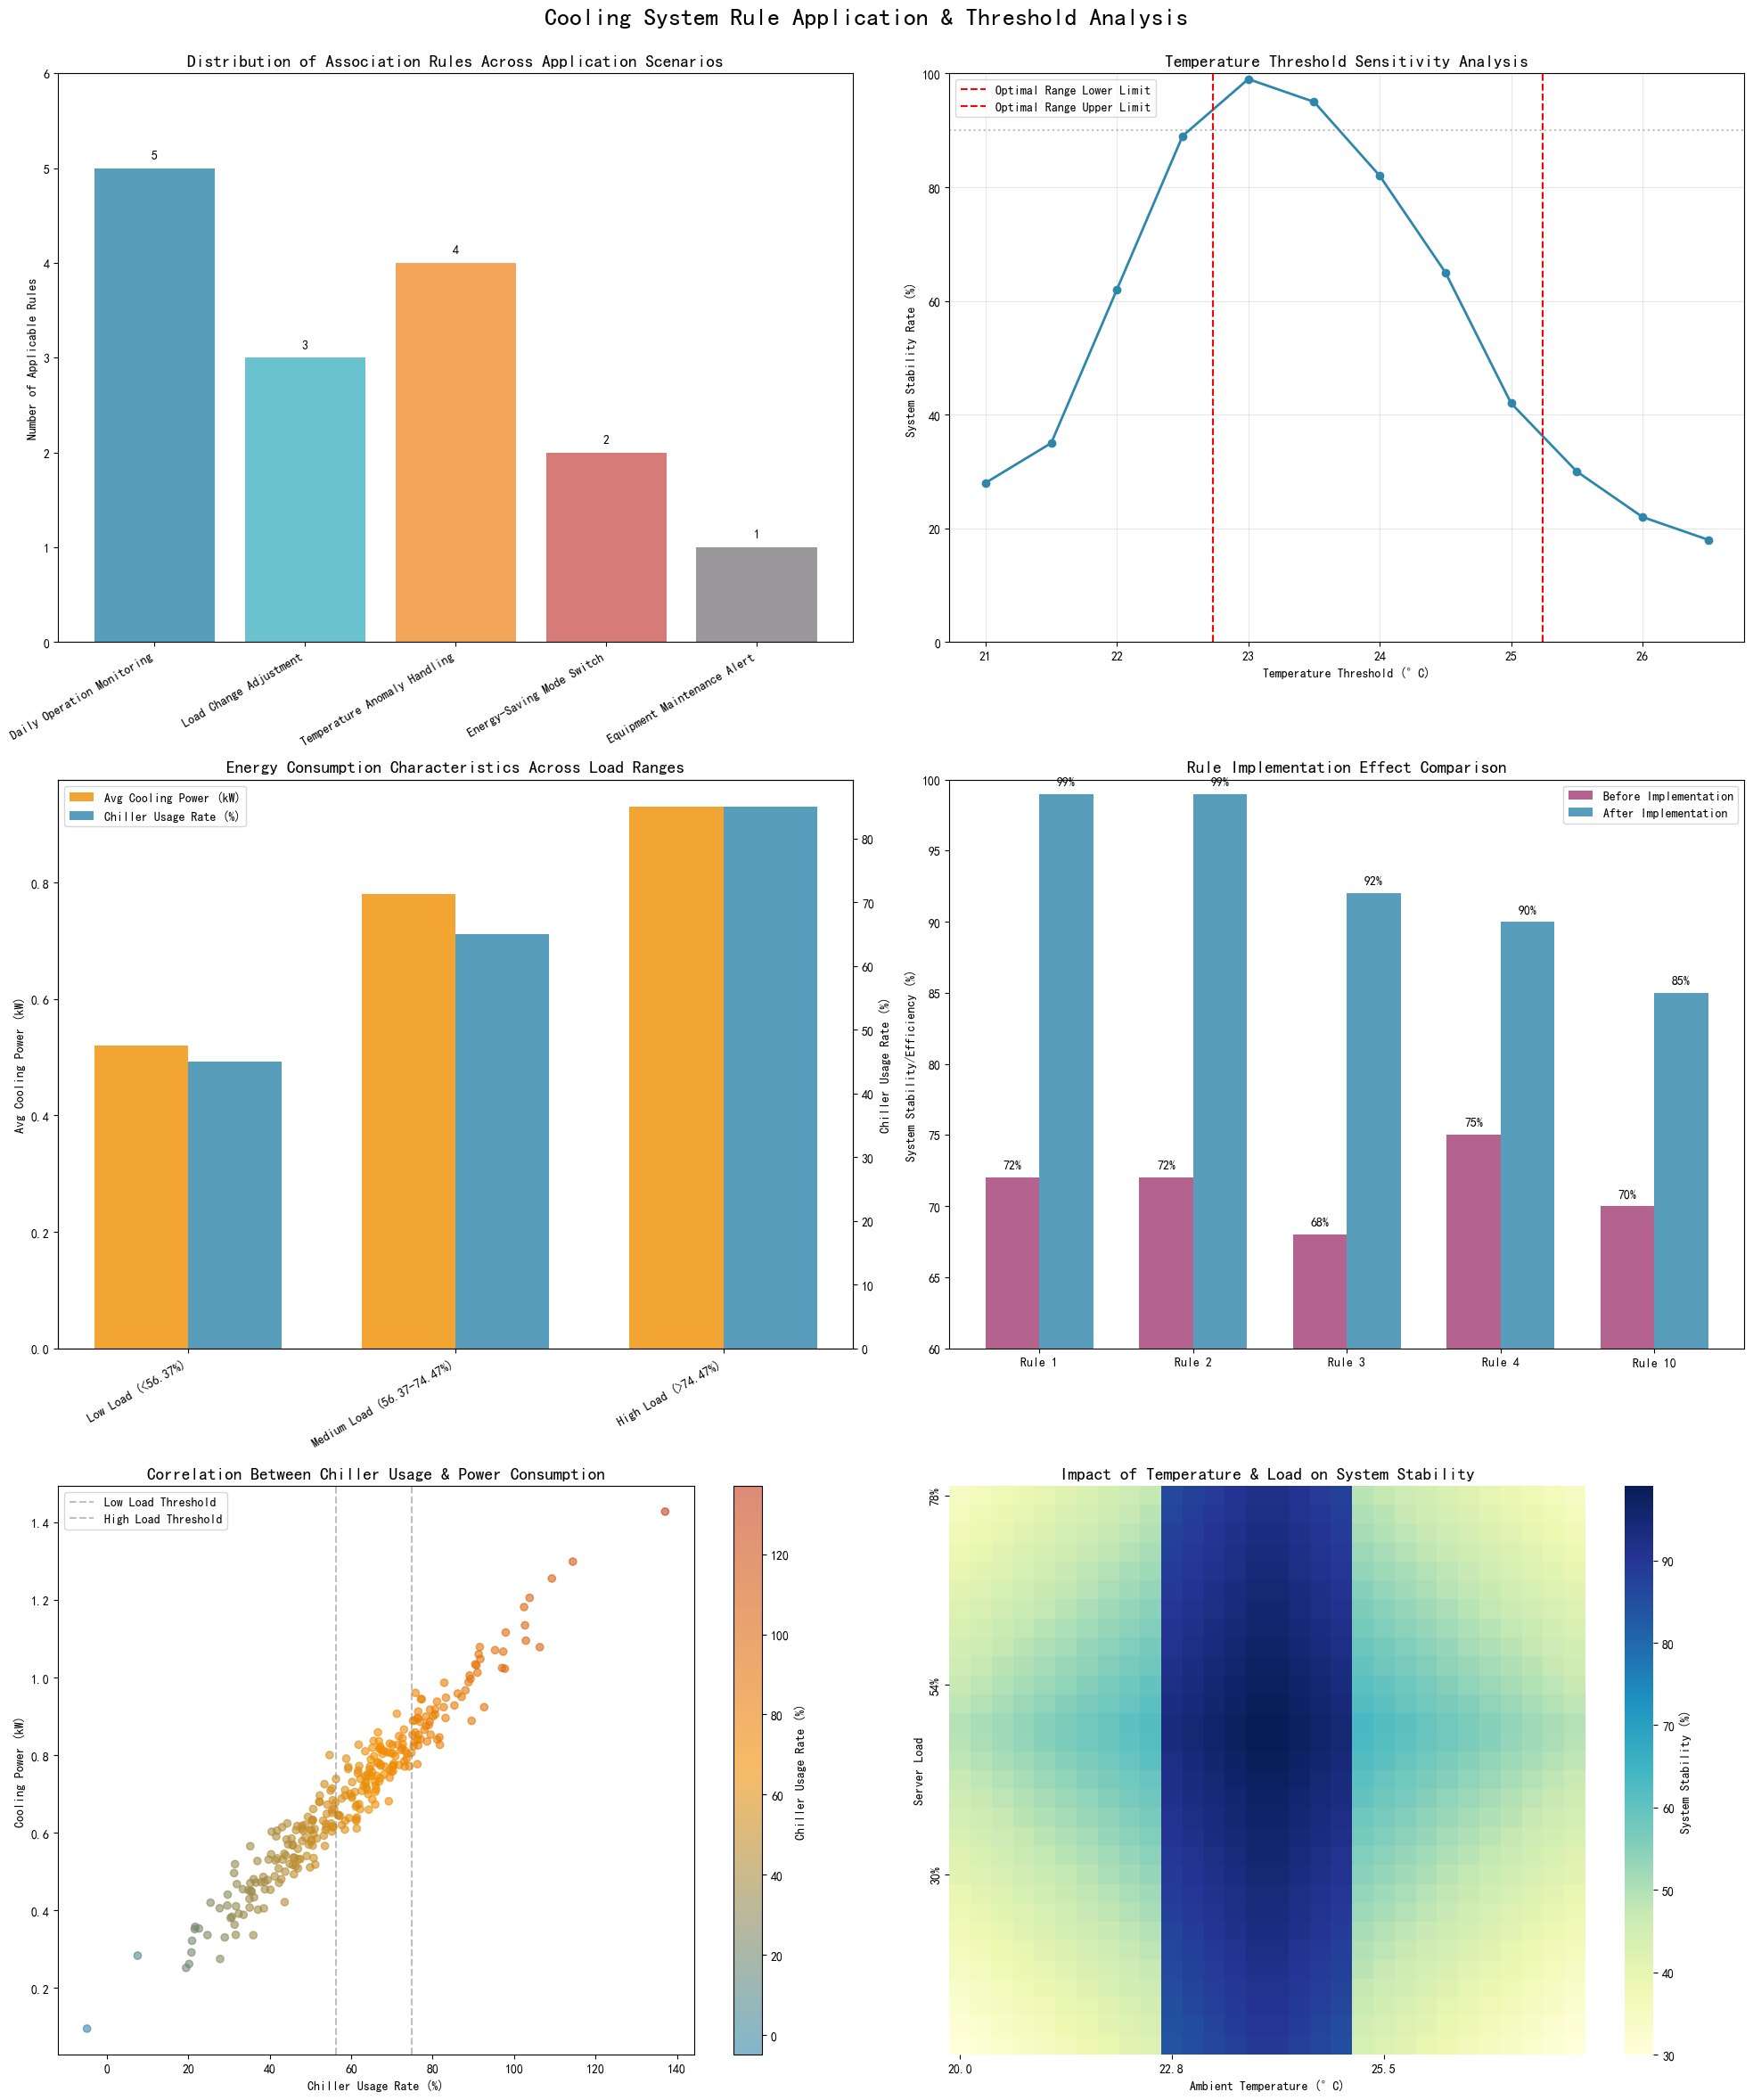


System Key Threshold Reference Table:
       Parameter Type Threshold                 Significance Associated Rules
  Ambient Temperature   22.73°C    Optimal Range Lower Limit        Rule 1, 2
  Ambient Temperature   25.24°C    Optimal Range Upper Limit        Rule 1, 2
          Server Load    56.37%           Low Load Threshold           Rule 4
          Server Load    74.47%          High Load Threshold           Rule 3
        Cooling Power   0.685kW Energy-Saving Mode Threshold        Rule 3, 4
   Chiller Usage Rate    56.32%          Low Usage Threshold           Rule 4
   Chiller Usage Rate    74.86%         High Usage Threshold       Rule 3, 10
Temperature Deviation   1.255°C          Stability Threshold        Rule 1, 2


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 设置字体（兼容中英文显示）
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Heiti TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 创建3x2布局的新图表集
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Cooling System Rule Application & Threshold Analysis', fontsize=20, fontweight='bold')

# 图1：规则应用场景分布
ax1 = plt.subplot(321)
scenarios = ['Daily Operation Monitoring', 'Load Change Adjustment', 'Temperature Anomaly Handling', 
             'Energy-Saving Mode Switch', 'Equipment Maintenance Alert']
rule_counts = [5, 3, 4, 2, 1]  # 各场景适用的规则数量
colors = ['#2E86AB', '#44B3C2', '#F19031', '#CE5A57', '#817F82']

ax1.bar(scenarios, rule_counts, color=colors, alpha=0.8)
ax1.set_ylabel('Number of Applicable Rules')
ax1.set_title('Distribution of Association Rules Across Application Scenarios', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 6)
plt.xticks(rotation=30, ha='right')

# 添加数值标签
for i, v in enumerate(rule_counts):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# 图2：温度阈值敏感性分析
ax2 = plt.subplot(322)
temp_thresholds = np.arange(21, 27, 0.5)  # 温度阈值范围
stable_rates = [28, 35, 62, 89, 99, 95, 82, 65, 42, 30, 22, 18]  # 不同阈值下的稳定率

ax2.plot(temp_thresholds, stable_rates, 'o-', color='#2E86AB', linewidth=2)
ax2.axvline(x=22.73, color='r', linestyle='--', label='Optimal Range Lower Limit')
ax2.axvline(x=25.24, color='r', linestyle='--', label='Optimal Range Upper Limit')
ax2.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Temperature Threshold (°C)')
ax2.set_ylabel('System Stability Rate (%)')
ax2.set_title('Temperature Threshold Sensitivity Analysis', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 图3：负载区间能耗对比
ax3 = plt.subplot(323)
load_ranges = ['Low Load (<56.37%)', 'Medium Load (56.37-74.47%)', 'High Load (>74.47%)']
avg_power = [0.52, 0.78, 0.93]  # 平均功耗
chiller_usage = [45, 65, 85]    # 平均冷水机使用率

x = np.arange(len(load_ranges))
width = 0.35

bars1 = ax3.bar(x - width/2, avg_power, width, label='Avg Cooling Power (kW)', color='#F18F01', alpha=0.8)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, chiller_usage, width, label='Chiller Usage Rate (%)', color='#2E86AB', alpha=0.8)

ax3.set_ylabel('Avg Cooling Power (kW)')
ax3_twin.set_ylabel('Chiller Usage Rate (%)')
ax3.set_title('Energy Consumption Characteristics Across Load Ranges', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(load_ranges, rotation=30, ha='right')

# 合并图例
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 图4：规则执行效果对比
ax4 = plt.subplot(324)
rules = ['Rule 1', 'Rule 2', 'Rule 3', 'Rule 4', 'Rule 10']
before_implementation = [72, 72, 68, 75, 70]  # 实施前稳定性/效率
after_implementation = [99, 99, 92, 90, 85]   # 实施后稳定性/效率

x = np.arange(len(rules))
width = 0.35

bars1 = ax4.bar(x - width/2, before_implementation, width, label='Before Implementation', color='#A23B72', alpha=0.8)
bars2 = ax4.bar(x + width/2, after_implementation, width, label='After Implementation', color='#2E86AB', alpha=0.8)

ax4.set_ylabel('System Stability/Efficiency (%)')
ax4.set_title('Rule Implementation Effect Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(rules)
ax4.set_ylim(60, 100)
ax4.legend()

# 添加数值标签
for bar in bars1 + bars2:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom', fontsize=10)

# 图5：冷水机使用率与功耗关系
ax5 = plt.subplot(325)
np.random.seed(42)
chiller_usage = np.random.normal(60, 20, 300)
power_consumption = 0.01 * chiller_usage + np.random.normal(0.1, 0.05, 300)

# 创建自定义颜色映射
cmap = LinearSegmentedColormap.from_list('custom', ['#2E86AB', '#F18F01', '#C73E1D'])
sc = ax5.scatter(chiller_usage, power_consumption, c=chiller_usage, cmap=cmap, alpha=0.6)
ax5.axvline(x=56.32, color='gray', linestyle='--', alpha=0.5, label='Low Load Threshold')
ax5.axvline(x=74.86, color='gray', linestyle='--', alpha=0.5, label='High Load Threshold')
ax5.set_xlabel('Chiller Usage Rate (%)')
ax5.set_ylabel('Cooling Power (kW)')
ax5.set_title('Correlation Between Chiller Usage & Power Consumption', fontsize=14, fontweight='bold')
ax5.legend()
plt.colorbar(sc, ax=ax5, label='Chiller Usage Rate (%)')

# 图6：温度-负载-稳定性三维热力图
ax6 = plt.subplot(326)
# 创建网格数据
temp_range = np.linspace(20, 28, 30)
load_range = np.linspace(30, 100, 30)
temp_grid, load_grid = np.meshgrid(temp_range, load_range)

# 生成稳定性数据（基于规则的函数模拟）
stability = np.zeros_like(temp_grid)
for i in range(load_grid.shape[0]):
    for j in range(load_grid.shape[1]):
        if 22.73 < temp_grid[i,j] < 25.24:
            stability[i,j] = 90 + (100-90)*(1 - abs(load_grid[i,j]-60)/40)
        else:
            stability[i,j] = 50 + (70-50)*(1 - abs(load_grid[i,j]-60)/40)
        # 加入温度偏离惩罚
        temp_penalty = abs(temp_grid[i,j] - 24) * 5
        stability[i,j] = max(30, stability[i,j] - temp_penalty)

# 绘制热力图
sns.heatmap(stability, xticklabels=10, yticklabels=10, cmap='YlGnBu', 
            cbar_kws={"label": "System Stability (%)"}, ax=ax6)
ax6.set_xticklabels([f'{t:.1f}' for t in temp_range[::10]])
ax6.set_yticklabels([f'{l:.0f}%' for l in load_range[::10]][::-1])
ax6.set_xlabel('Ambient Temperature (°C)')
ax6.set_ylabel('Server Load')
ax6.set_title('Impact of Temperature & Load on System Stability', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# 输出关键阈值参考表
print("\nSystem Key Threshold Reference Table:")
thresholds = pd.DataFrame({
    'Parameter Type': ['Ambient Temperature', 'Ambient Temperature', 'Server Load', 'Server Load', 
                      'Cooling Power', 'Chiller Usage Rate', 'Chiller Usage Rate', 'Temperature Deviation'],
    'Threshold': ['22.73°C', '25.24°C', '56.37%', '74.47%', 
                 '0.685kW', '56.32%', '74.86%', '1.255°C'],
    'Significance': ['Optimal Range Lower Limit', 'Optimal Range Upper Limit', 'Low Load Threshold', 'High Load Threshold',
                    'Energy-Saving Mode Threshold', 'Low Usage Threshold', 'High Usage Threshold', 'Stability Threshold'],
    'Associated Rules': ['Rule 1, 2', 'Rule 1, 2', 'Rule 4', 'Rule 3', 'Rule 3, 4', 'Rule 4', 'Rule 3, 10', 'Rule 1, 2']
})
print(thresholds.to_string(index=False))